# 13 - The MIS3 reconstruction

The three evaluation lanes exist to choose an estimator. That choice is made, so this
notebook stops measuring and produces the thing the measurements were for: MTCO and MTWA
fields at every one of the 804 ages, from the real pollen network, with HGAOEnKF-MT.

Nothing here is scored. There is no truth at these ages, and the honest statements about
what the product supports come from the trajectory lane, which measured the same estimator
against model states, and from the withholding lane, which measured it against real pollen.
Both are read back at the end.

## The operating point

`k`, `hybrid_w`, the evidence rule and the flow stack are inherited from the PPE grid rather
than retyped, so the product runs at a point some lane actually selected. What this notebook
decides is `b_scale`, and the three lanes appear to disagree about it by a factor of twenty.
They do not, once each is read for what it measures.

- The PPE lane selects 10, but it averages the analysis over five noise draws, so its
  effective observation error is a fifth of the R it assimilates under. A single-realisation
  product should read that selection as roughly 2.
- The trajectory lane selects 0.5 on pooled RRMSE, which is dominated by the 25-year grid.
  This project does not claim skill at 25 years. Selected on the same lane and the same
  selection split at the resolution the product does claim, the choice moves: the 250-year
  low-pass CE peaks at 5, and so does the 500-year.
- The withholding lane, the only one whose truth is independent of the model, is flat from 5
  to 20.

So `b_scale = 5` is the trajectory lane's optimum at the resolution the product claims, and
it sits inside the flat optimum of the other two. It is written alongside 1 and 10, which
cost nothing extra because the covariance build is shared across the sweep, and the spread
between them is what says how much the choice mattered.

In [1]:
%load_ext autoreload
%autoreload 2

# Cap BLAS threading before numpy loads, for the same reason notebook 07 does: the
# assimilation runs thousands of small eigendecompositions, a size where splitting each one
# across cores costs more than it saves.
import os

for _var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
             "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_var] = "1"

import json
import shutil
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

from paleoreco.data import VARS, build_prior_cube
from paleoreco.data.splits import DO_EVENT_WINDOWS
from paleoreco.assim.analog import ANALOG_EVIDENCE
from paleoreco.assim.hgaoenkf import make_hgaoenkf
from paleoreco.assim.innovation import nearest_lat_index, nearest_lon_index
from paleoreco.assim.observations import (
    attach_site_stats, collapse_to_samples, load_observations, observation_site_stats,
)
from paleoreco.assim.reconstruction import run_reconstruction
from paleoreco.assim import experiments as ex
from paleoreco.eval import da

plt.rcParams["figure.dpi"] = 110
DATA = "../data"
OUT = Path("../outputs/da")
FIG = Path("../outputs/figures/13_reconstruction")
FIG.mkdir(parents=True, exist_ok=True)

# The product is one run; the variants answer how much the operating point mattered and
# cost about a minute each.
RUN_PRODUCT = True
RUN_SENSITIVITY = False

RULE = ANALOG_EVIDENCE
ESTIMATOR = ex.ESTIMATOR_HGAOENKF_MT
PRODUCT = OUT / f"{ESTIMATOR}_reconstruction"

# b_scale = 5 leads; 1 and 10 bracket it and ride in the same sweep.
B_SCALES = (1.0, 5.0, 10.0)
B_LEAD = 5.0

## Inputs and the inherited operating point

The prior spans every age, as the withholding lane's does, so the analog pool contains the
age being reconstructed and the exclusion band is what keeps the analysis from selecting the
simulation's own state there.

In [2]:
P = build_prior_cube(prior_csv=f"{DATA}/Prior.csv", cache_path=f"{DATA}/cache/prior_cube.npz")
cube, ages, lats, lons, valid = P["cube"], P["ages"], P["lats"], P["lons"], P["valid"]

long = load_observations(f"{DATA}/Observation.csv")
long = attach_site_stats(long, observation_site_stats(collapse_to_samples(long)))

PPE_CFG = json.load(open(OUT / f"{ESTIMATOR}_pixel" / "ppe_config.json"))
TAPER = {k: PPE_CFG["selected"].get(k, PPE_CFG[k])
         for k in ("localization_km", "shrinkage_lambda", "alpha")}
K_SEL = int(PPE_CFG["selected"]["analog_k"])
W_SEL = float(PPE_CFG["selected"]["hybrid_w"])
TERMS = {k: float(PPE_CFG["selected"][k]) for k in ex.TERM_KEYS}
STACK = dict(tendency_extra_lags_yr=tuple(PPE_CFG["tendency_extra_lags_yr"]),
             tendency_curvature_yr=tuple(PPE_CFG["tendency_curvature_yr"]),
             tendency_normalise=True, preserve_obs_trace=True)

print(f"cube {cube.shape}, {len(ages)} ages {ages.min()}-{ages.max()} yr BP")
print(f"network: {long['site'].nunique()} sites, {long['age'].nunique()} distinct ages")
print(f"taper inherited from the PPE grid: {TAPER}")
print(f"k={K_SEL}, hybrid_w={W_SEL}, flow weight {TERMS['tendency_theta']:g} at "
      f"reference lag {TERMS['tendency_lag_yr']:.0f} yr")
print(f"exclusion band {ex.EXCLUDE_YR:.0f} yr, staleness treatment "
      f"{ex.TEMPORAL_DEFLATE}, b_scale {B_SCALES} (lead {B_LEAD:g})")

cube (804, 2, 32, 64), 804 ages 29100-49175 yr BP
network: 187 sites, 768 distinct ages
taper inherited from the PPE grid: {'localization_km': 15000.0, 'shrinkage_lambda': 0.0, 'alpha': 0.25}
k=60, hybrid_w=1.0, flow weight 2 at reference lag 400 yr
exclusion band 1000 yr, staleness treatment deflate, b_scale (1.0, 5.0, 10.0) (lead 5)


## Run

One analysis per age. Ages whose network is empty carry the prior instead, flagged, so a
climatology is never passed off as a reconstruction.

In [3]:
def product_method(cube, ages, **over):
    """The estimator the product runs, with any argument overridden for a variant."""
    kw = dict(k=K_SEL, hybrid_w=W_SEL, selection=RULE, exclude_yr=ex.EXCLUDE_YR,
              **TERMS, **STACK)
    kw.update(over)
    if kw["tendency_theta"] <= 0.0:            # a stack needs a weight to be anything
        for key in ("tendency_extra_lags_yr", "tendency_curvature_yr",
                    "tendency_normalise", "preserve_obs_trace"):
            kw.pop(key, None)
        kw["tendency_lag_yr"] = 0.0
    return make_hgaoenkf(cube, ages, lats, lons, **kw)


if RUN_PRODUCT:
    shutil.rmtree(PRODUCT, ignore_errors=True)
    t0 = time.time()
    CFG = run_reconstruction(
        cube, ages, lats, lons, valid, long, str(PRODUCT),
        make_method=product_method(cube, ages), b_scales=B_SCALES,
        temporal_mode=ex.TEMPORAL_DEFLATE, estimator=ESTIMATOR,
        method_cols=ex.analog_cols(K_SEL, W_SEL, **TERMS, tendency_normalise=True,
                                   preserve_obs_trace=True),
        progress_every=100, **TAPER)
    print(f"  done in {time.time() - t0:.0f}s")
else:
    CFG = json.load(open(PRODUCT / "reconstruction_config.json"))
    print("product run off; reading the last one")

Z = np.load(PRODUCT / "reconstruction_fields.npz")
BJ = int(np.argmin(np.abs(Z["b_scales"] - B_LEAD)))
AGES, SAFE, CLIM = Z["ages"], Z["safe_valid"], Z["clim_mean"]
LIVE = ~Z["prior_only"]

print(f"{CFG['n_ages']} ages, {CFG['n_prior_only_ages']} carrying the prior alone")
print(f"observation ages off the archive's axis: {CFG['n_obs_ages_off_axis']}")
print(f"representativeness variance: "
      f"{ {k: round(v, 3) for k, v in CFG['rep_var_full'].items()} }")

  reconstruction age 100/804 (12%, elapsed 16s, eta 111s)
  reconstruction age 200/804 (25%, elapsed 36s, eta 110s)
  reconstruction age 300/804 (37%, elapsed 54s, eta 91s)
  reconstruction age 400/804 (50%, elapsed 73s, eta 74s)
  reconstruction age 500/804 (62%, elapsed 89s, eta 54s)
  reconstruction age 600/804 (75%, elapsed 107s, eta 36s)
  reconstruction age 700/804 (87%, elapsed 126s, eta 19s)
  reconstruction age 800/804 (100%, elapsed 143s, eta 1s)
  done in 149s
804 ages, 36 carrying the prior alone
observation ages off the archive's axis: 0
representativeness variance: {'mtco': 2.444, 'mtwa': 0.422}


## How much the operating point mattered

Each variant is the product rerun with one thing changed: the flow stack switched off, which
is this estimator's own mechanism ablated on the real reconstruction rather than on a lane;
and the withholding lane's operating point, which is the cross-lane check the choice of
`b_scale` above left open. The exclusion band is swept because its width appears in no
paper, so the only thing that justifies 1000 yr is showing what other widths do.

In [4]:
VARIANTS = {
    "no_flow": dict(over=dict(tendency_theta=0.0), taper=TAPER, note="flow stack off"),
    "withholding_point": dict(over=dict(k=100), taper=None, note="the other lane's point"),
    "exclude_0": dict(over=dict(exclude_yr=0.0), taper=TAPER, note="no exclusion band"),
    "exclude_2000": dict(over=dict(exclude_yr=2000.0), taper=TAPER, note="2000 yr band"),
}

if RUN_SENSITIVITY:
    wh = json.load(open(OUT / f"{ESTIMATOR}_pixel" / "withholding_random_config.json"))
    taper_wh = {k: wh[k] for k in ("localization_km", "shrinkage_lambda", "alpha")}
    for name, spec in VARIANTS.items():
        path = PRODUCT.parent / f"{PRODUCT.name}_{name}"
        shutil.rmtree(path, ignore_errors=True)
        t0 = time.time()
        run_reconstruction(
            cube, ages, lats, lons, valid, long, str(path),
            make_method=product_method(cube, ages, **spec["over"]), b_scales=B_SCALES,
            temporal_mode=ex.TEMPORAL_DEFLATE, estimator=ESTIMATOR,
            **(spec["taper"] or taper_wh))
        print(f"  {name} ({spec['note']}) done in {time.time() - t0:.0f}s", flush=True)
else:
    print("sensitivity variants off; set RUN_SENSITIVITY = True to produce them")

rows = []
for name, spec in VARIANTS.items():
    path = PRODUCT.parent / f"{PRODUCT.name}_{name}" / "reconstruction_fields.npz"
    if not path.exists():
        continue
    v = np.load(path)
    d = v["mean_anom"][BJ] - Z["mean_anom"][BJ]
    rows.append({"variant": name, "what changed": spec["note"],
                 "rms difference (degC)": float(np.sqrt((d[:, :, SAFE] ** 2).mean())),
                 "amplitude ratio": float(v["mean_anom"][BJ][:, :, SAFE].std()
                                          / Z["mean_anom"][BJ][:, :, SAFE].std())})
if rows:
    print("\nEach variant against the product, over every age and unmasked cell:")
    display(pd.DataFrame(rows).set_index("variant").round(4))

sensitivity variants off; set RUN_SENSITIVITY = True to produce them


## What stood behind each age

The network runs from nothing to 118 sites, and the youngest 1000 years carry no pollen at
all. Every panel below has to be read against this one: where the count is low the analysis
returns most of the way to the prior, and where it is zero the field *is* the prior.

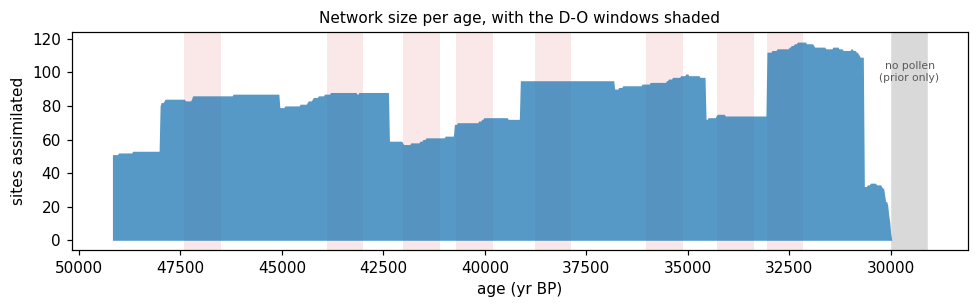

sites per age: median 87, range 4-118 where any were assimilated
36 ages carry the prior alone (29100-29975 yr BP)


In [5]:
fig, ax = plt.subplots(figsize=(9, 2.9))
ax.fill_between(AGES, 0, Z["n_sites"], color="C0", lw=0, alpha=0.75)
gap = AGES[Z["prior_only"]]
if len(gap):
    ax.axvspan(gap.min(), gap.max(), color="0.85", zorder=0)
    ax.text(gap.mean(), Z["n_sites"].max() * 0.85, "no pollen\n(prior only)",
            ha="center", va="center", fontsize=7, color="0.35")
for lo, hi in DO_EVENT_WINDOWS.values():
    ax.axvspan(lo, hi, color="C3", alpha=0.10, lw=0, zorder=0)
ax.set_xlabel("age (yr BP)")
ax.set_ylabel("sites assimilated")
ax.set_title("Network size per age, with the D-O windows shaded", fontsize=10)
ax.invert_xaxis()
fig.tight_layout()
fig.savefig(FIG / "network_per_age.png", bbox_inches="tight")
plt.show()

print(f"sites per age: median {int(np.median(Z['n_sites'][LIVE]))}, "
      f"range {Z['n_sites'][LIVE].min()}-{Z['n_sites'].max()} where any were assimilated")
print(f"{int((~LIVE).sum())} ages carry the prior alone "
      f"({AGES[~LIVE].min()}-{AGES[~LIVE].max()} yr BP)")

## Is the amplitude balance right?

The lanes chose `b_scale` against a truth. The product has none, but it can still ask whether
the assumed observation error matches the residuals it actually produced. Desroziers (2005)
gives the check: `E[d_a d_b'] = R`, so the ratio of that product to the assumed R is 1 when
the background and observation error are in the right proportion, above 1 when the prior is
carrying more weight than the residuals justify.

This is the one statement about `b_scale` that comes from the real proxies and the real prior
rather than from any lane, so read it as corroboration or as a flag, not as a re-selection.

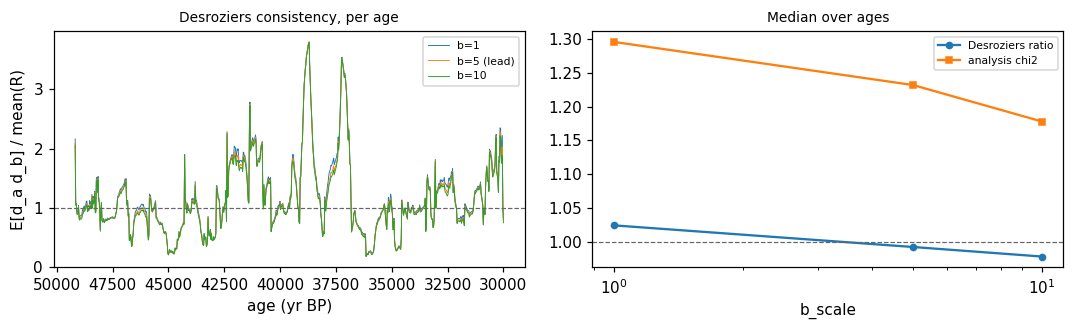

background innovation against R: median chi2 1.354 (1 means R alone explains the misfit)


,desroziers,chi2 analysis
b_scale,,
1.0,1.024,1.296
5.0,0.992,1.232
10.0,0.978,1.178


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.1))
for j, b in enumerate(Z["b_scales"]):
    axes[0].plot(AGES, Z["desroziers_r"][j], lw=0.6,
                 label=f"b={b:g}" + (" (lead)" if j == BJ else ""))
axes[0].axhline(1.0, color="0.4", lw=0.8, ls="--")
axes[0].set_ylabel("E[d_a d_b] / mean(R)")
axes[0].set_title("Desroziers consistency, per age", fontsize=9)
axes[0].legend(fontsize=7)

tab = pd.DataFrame({
    "b_scale": Z["b_scales"],
    "desroziers": [np.nanmedian(Z["desroziers_r"][j]) for j in range(len(Z["b_scales"]))],
    "chi2 analysis": [np.nanmedian(Z["chi2_an"][j]) for j in range(len(Z["b_scales"]))],
}).set_index("b_scale")
axes[1].plot(tab.index, tab["desroziers"], marker="o", ms=4, label="Desroziers ratio")
axes[1].plot(tab.index, tab["chi2 analysis"], marker="s", ms=4, label="analysis chi2")
axes[1].axhline(1.0, color="0.4", lw=0.8, ls="--")
axes[1].set_xscale("log")
axes[1].set_xlabel("b_scale")
axes[1].set_title("Median over ages", fontsize=9)
axes[1].legend(fontsize=7)
for ax in axes:
    ax.set_xlabel(ax.get_xlabel() or "age (yr BP)")
axes[0].invert_xaxis()
fig.tight_layout()
fig.savefig(FIG / "amplitude_balance.png", bbox_inches="tight")
plt.show()

print(f"background innovation against R: median chi2 "
      f"{np.nanmedian(Z['chi2_bg']):.3f} (1 means R alone explains the misfit)")
display(tab.round(3))

## The reconstruction

Two views of the same fields. The area-weighted mean over unmasked cells says what the
whole domain does; one cell in the Nordic Seas, which carries the largest D-O signal in the
prior, says what a place does. Both are drawn raw and at 250 years, the resolution the
product supports; the shaded band is the spread across `b_scale`, which is the operating
point's own contribution to the answer.

The faint grey line is LOVECLIM's own state at each age, in the same anomaly frame and
low-passed to the same 250 years, so the two are comparable directly. Read the gap with two
things in mind. It is not the gap between the analysis and the prior it actually started
from: the analog ensemble is drawn from elsewhere in the archive and the exclusion band
keeps the simulation's state at the target age out of it, so this grey line never entered
the analysis at that age. And the proxy chronology was warped against this same simulation,
so agreement in timing is partly built in, while the size of the departures is not.

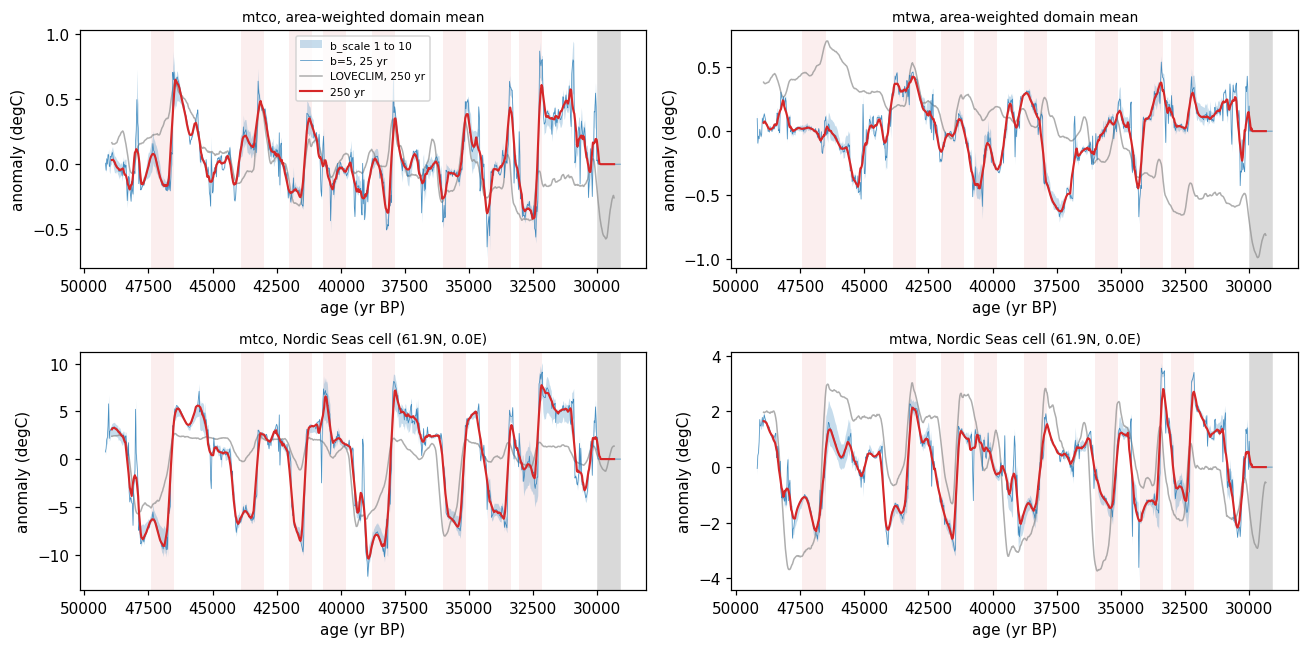

In [7]:
WEIGHT = np.cos(np.deg2rad(lats))[:, None] * SAFE
WEIGHT = WEIGHT / WEIGHT.sum()
NORDIC = (nearest_lat_index(np.array([61.9]), lats)[0],
          nearest_lon_index(np.array([2.8]), lons)[0])
STEP_YR = float(np.diff(AGES)[0])


def series(field, place):
    """One index through time: an area-weighted domain mean, or a single cell."""
    return (field * WEIGHT).sum(axis=(-2, -1)) if place is None else field[..., place[0], place[1]]


# The simulation on the product's own anomaly frame, since clim_mean is its mean over these
# same ages. Nothing is regridded: the archive is what the reconstruction was built on.
LOVECLIM = cube.astype(np.float64) - CLIM

PLACES = [(None, "area-weighted domain mean"),
          (NORDIC, f"Nordic Seas cell ({lats[NORDIC[0]]:.1f}N, {lons[NORDIC[1]]:.1f}E)")]
fig, axes = plt.subplots(len(PLACES), 2, figsize=(12, 3.0 * len(PLACES)), squeeze=False)
for ri, (place, label) in enumerate(PLACES):
    for ci, ch in enumerate(VARS):
        ax = axes[ri, ci]
        band = np.stack([series(Z["mean_anom"][j, :, ci], place)
                         for j in range(len(Z["b_scales"]))])
        smooth = da.lowpass_time(series(Z["mean_anom"][BJ, :, ci], place), 250, STEP_YR)
        prior = da.lowpass_time(series(LOVECLIM[:, ci], place), 250, STEP_YR)
        trim = da.timescale_trim(250, STEP_YR)
        keep = slice(trim, len(AGES) - trim)
        ax.fill_between(AGES, band.min(axis=0), band.max(axis=0), color="C0", alpha=0.25,
                        lw=0, label="b_scale 1 to 10")
        ax.plot(AGES, band[BJ], color="C0", lw=0.5, alpha=0.8, label=f"b={B_LEAD:g}, 25 yr")
        # Behind the analysis, and at its smoothing, so the comparison is like for like.
        ax.plot(AGES[keep], prior[keep], color="0.55", lw=1.0, alpha=0.7, zorder=1,
                label="LOVECLIM, 250 yr")
        ax.plot(AGES[keep], smooth[keep], color="C3", lw=1.4, label="250 yr")
        if len(gap):
            ax.axvspan(gap.min(), gap.max(), color="0.85", zorder=0)
        for lo, hi in DO_EVENT_WINDOWS.values():
            ax.axvspan(lo, hi, color="C3", alpha=0.08, lw=0, zorder=0)
        ax.set_title(f"{ch}, {label}", fontsize=9)
        ax.set_xlabel("age (yr BP)")
        ax.set_ylabel("anomaly (degC)")
        ax.invert_xaxis()
        if ri == 0 and ci == 0:
            ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIG / "reconstruction_series.png", bbox_inches="tight")
plt.show()

## D-O warming, and the seasonal contrast

Each window runs from 300 years before a GI onset to 600 after, so the interstadial half is
the younger 300 years and the stadial half the older 600. The difference between them is the
warming magnitude, which is the claim the chronology supports; a rate of change is not, since
the dynamic time warp that aligned these records precludes it.

The seasonality column is `MTWA - MTCO`. It matters more than either channel on its own here:
the warp was fitted on mean annual temperature, so the contrast between the two seasons is the
part of the signal least affected by it. Its uncertainty needs the covariance between the two
channels, which the posterior carries: they are strongly correlated, so their errors largely
cancel in the difference and adding the two variances would overstate the bar by a wide margin.

In [8]:
def window_mean(field, lo, hi):
    """Mean of a per-age field over an inclusive age window, ignoring prior-only ages."""
    sel = (AGES >= lo) & (AGES <= hi) & LIVE
    return field[sel].mean(axis=0) if sel.any() else np.full(field.shape[1:], np.nan)


mean_b, var_b = Z["mean_anom"][BJ], Z["post_var"][BJ]
cross_b = Z["post_cross_var"][BJ]
rows = []
for event, (lo, hi) in sorted(DO_EVENT_WINDOWS.items()):
    onset = lo + 300
    warm = {ch: window_mean(mean_b[:, ci], lo, onset) - window_mean(mean_b[:, ci], onset, hi)
            for ci, ch in enumerate(VARS)}
    seas = warm["mtwa"] - warm["mtco"]
    # Var(mtwa - mtco) needs the cross term; the two channels move together, so dropping it
    # would inflate the bar rather than leave it merely approximate.
    sel = (AGES >= lo) & (AGES <= hi) & LIVE
    sd = np.sqrt(np.clip(var_b[sel, 1] + var_b[sel, 0] - 2 * cross_b[sel], 0, None)).mean(axis=0)
    naive = np.sqrt(var_b[sel, 1] + var_b[sel, 0]).mean(axis=0)
    rows.append({"event": event, "onset (yr BP)": onset,
                 "MTCO (degC)": float((warm["mtco"] * WEIGHT).sum()),
                 "MTWA (degC)": float((warm["mtwa"] * WEIGHT).sum()),
                 "seasonality (degC)": float((seas * WEIGHT).sum()),
                 "seasonality sd": float((sd * WEIGHT).sum()),
                 "sd if cross dropped": float((naive * WEIGHT).sum())})
comp = pd.DataFrame(rows).set_index("event")
print("Interstadial minus stadial, area-weighted over unmasked cells:")
display(comp.round(3))
print(f"\nIgnoring the channel covariance would overstate the seasonality error bar by "
      f"{comp['sd if cross dropped'].mean() / comp['seasonality sd'].mean():.1f}x.")

Interstadial minus stadial, area-weighted over unmasked cells:


,onset (yr BP),MTCO (degC),MTWA (degC),seasonality (degC),seasonality sd,sd if cross dropped
event,,,,,,
5,32450,0.460,0.145,-0.316,0.574,0.724
6,33670,0.308,0.297,-0.011,0.481,0.655
7,35420,0.217,0.082,-0.134,0.566,0.705
8,38170,0.143,-0.385,-0.528,0.616,0.769
9,40110,0.041,0.074,0.034,0.585,0.731
10,41410,0.520,0.148,-0.372,0.461,0.620
11,43290,0.278,0.059,-0.219,0.468,0.611
12,46810,0.059,-0.062,-0.121,0.410,0.560



Ignoring the channel covariance would overstate the seasonality error bar by 1.3x.


## Maps

The composite warming across all eight events, and the seasonal contrast alongside. Sites are
overlaid at their assimilated positions; away from them the analysis returns toward the
analog prior, which is what the skill-versus-distance curve in notebook 09 quantifies.

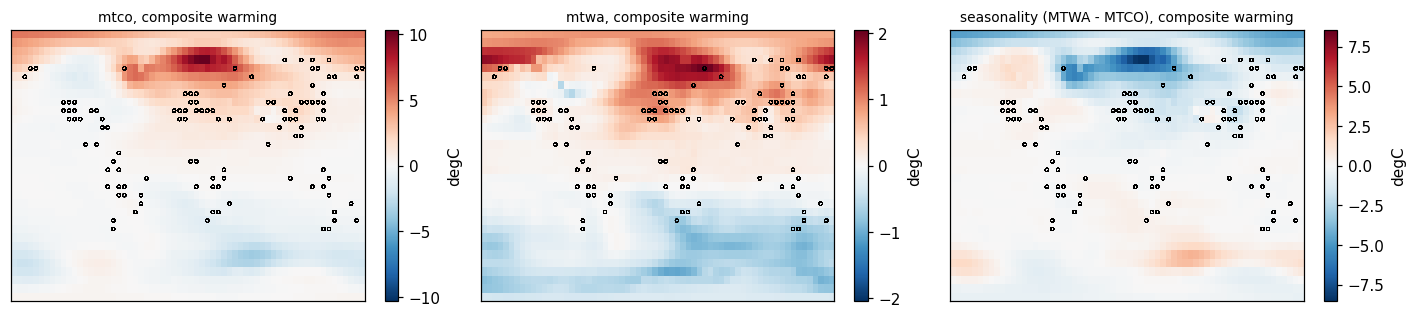

In [9]:
onsets = {e: lo + 300 for e, (lo, hi) in DO_EVENT_WINDOWS.items()}
stack = {ch: np.nanmean([window_mean(mean_b[:, ci], lo, onsets[e])
                         - window_mean(mean_b[:, ci], onsets[e], hi)
                         for e, (lo, hi) in sorted(DO_EVENT_WINDOWS.items())], axis=0)
         for ci, ch in enumerate(VARS)}
stack["seasonality (MTWA - MTCO)"] = stack["mtwa"] - stack["mtco"]

site_lat = nearest_lat_index(long["lat"].to_numpy(), lats)
site_lon = nearest_lon_index(long["lon"].to_numpy(), lons)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.0))
for ax, (name, field) in zip(axes, stack.items()):
    vlim = float(np.nanmax(np.abs(np.where(SAFE, field, np.nan))) + 1e-9)
    im = ax.imshow(np.where(SAFE, field, np.nan), origin="lower", cmap="RdBu_r",
                   vmin=-vlim, vmax=vlim, aspect="auto")
    ax.scatter(site_lon, site_lat, s=5, facecolors="none", edgecolors="k", linewidths=0.25)
    ax.set_title(f"{name}, composite warming", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, label="degC")
fig.tight_layout()
fig.savefig(FIG / "do_composite_maps.png", bbox_inches="tight")
plt.show()

## What the product supports

Two statements, both measured elsewhere on this same estimator and both read here at the
`b_scale` the product actually runs at.

**Resolution.** The trajectory lane reconstructed a consecutive run of model states with the
real network geometry and scored it by timescale. The product is published on a 25-year grid,
as Osman et al. (2021) and Erb et al. (2022) publish theirs, but the grid is not the claim:
the claim is the row of this table where CE is worth quoting, and the amplitude ratio next to
it says whether the size is right as well as the shape.

**Error bars.** The same lane says whether the posterior spread is honest. A dispersion above
1 means the stated uncertainty is too tight and should be widened by that factor before
anything is read off it.

In [10]:
TRAJ = OUT / f"{ESTIMATOR}_pixel_trajectory" / "metrics.csv"
if not TRAJ.exists():
    print("no trajectory lane on disk; run notebook 12 first")
else:
    m = pd.read_csv(TRAJ)
    sel = m[(m.method == ex.method_label(ESTIMATOR, ex.TEMPORAL_DEFLATE))
            & (m.split == "test") & (m.channel == "pooled") & (m.do_event == "all")
            & np.isclose(m.b_scale, B_LEAD)]
    rows = []
    for w in ex.LOWPASS_WINDOWS:
        get = lambda metric: sel[sel.metric == f"{metric}_lp{w}"]["value"]
        if len(get("ce")):
            rows.append({"smoothed to (yr)": w, "CE": float(get("ce").iloc[0]),
                         "correlation": float(get("corr").iloc[0]),
                         "amplitude": float(get("amp").iloc[0])})
    print(f"Trajectory lane, held-out half, at the product's b_scale = {B_LEAD:g}:")
    display(pd.DataFrame(rows).set_index("smoothed to (yr)").round(3))

    cal = {r: float(sel[sel.metric == r]["value"].iloc[0])
           for r in ("rcrv_dispersion", "coverage90") if len(sel[sel.metric == r])}
    if cal:
        print(f"\nposterior spread: dispersion {cal['rcrv_dispersion']:.2f} "
              f"(1.0 is honest), 90% coverage {cal['coverage90']:.2f}")
        print(f"inflate the stated standard deviation by "
              f"{cal['rcrv_dispersion']:.2f}x before reading an interval off it")

Trajectory lane, held-out half, at the product's b_scale = 5:


,CE,correlation,amplitude
smoothed to (yr),,,
25,0.527,0.750,1.088
100,0.698,0.862,1.054
250,0.752,0.898,1.060
500,0.756,0.918,1.113
1000,0.773,0.944,1.210
2000,0.772,0.992,0.998



posterior spread: dispersion 1.34 (1.0 is honest), 90% coverage 0.82
inflate the stated standard deviation by 1.34x before reading an interval off it


## Reading

- **The grid is 25 years; the claim is not.** Quote the smoothed rows above. The fastest
  bands carry little variance and the analog set turns over between neighbouring analyses,
  which puts high-frequency structure into the series that did not come from the pollen.
- **Magnitude and pattern, never rate.** Liu et al. (2026) sec 4.4 say the dynamic time
  warping "precludes the calculation of a rate of change in climate". The composites above are
  differences between two windows, which is what the chronology supports.
- **Disclose the circularity.** The proxy chronology was warped against the same simulation
  that supplies the prior, so the timing agreement is partly built in. The quantitative bound
  is that pollen pairs reach only about 30% of the simulation's own inter-site correlation, and
  the gain is 20:1 in favour of near pairs over far ones, so the warp nudged the records rather
  than overwriting them. Lean on the seasonal contrast, which the warp did not touch.
- **The proxy anomaly frame is not the model's.** Observations enter against each site's own
  record mean, and half the sites cover less than half the interval, so their frame differs
  from the 20 kyr climatology by about 0.3 degC rms. It is a per-site constant of a few per
  cent of the assimilated error variance, and it cancels in the composites above, which are
  differences.
- **Uncertainty is under-dispersive** by the factor the last cell prints, and the network
  count panel says where it is worst. The 36 prior-only ages carry the climatology and its
  full prior variance; nothing was reconstructed there.
- **The variants say how much the operating point mattered.** Where their rms difference is
  small next to the signal, the choice of `b_scale` and of lane is not carrying the result.